<h1 style="font-size:3rem;color:black;">Prédiction du type histologique des cancers de l’endomètre</h1>

### (TCGA-UCEC)

# 1. Introduction et objectifs

Les cancers de l’endomètre constituent un groupe hétérogène de tumeurs présentant des différences biologiques et cliniques marquées selon leur type histologique, notamment entre les carcinomes endométrioïdes et séreux.
L’objectif de ce travail est d’évaluer dans quelle mesure l’expression génique permet de prédire le type histologique des tumeurs de l’endomètre, à l’aide de modèles d’apprentissage supervisé.

Nous comparons ici une approche linéaire interprétable (régression logistique) à un modèle de deep learning (réseau de neurones multicouche, MLP), afin d’analyser les performances prédictives et les signaux biologiques capturés par chaque méthode.

# 2. Chargement des données et environnement

Dans cette section, nous chargeons :

-la matrice d’expression génique issue du jeu de données TCGA-UCEC,

-les annotations cliniques associées aux patients.

Nous vérifions la cohérence des identifiants entre les différentes sources de données et examinons les dimensions globales du jeu de données.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import random
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["PYTHONHASHSEED"] = "42"
random.seed(42)
np.random.seed(42)


from scikeras.wrappers import KerasClassifier

from scipy.stats import randint, uniform

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_curve,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
    make_scorer,
    accuracy_score, 
    balanced_accuracy_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers

tf.random.set_seed(42)

from scikeras.wrappers import KerasClassifier

print(sys.executable)




X_genes = pd.read_csv(
    "/Users/quentin/Desktop/AI-DL_TCGA/tcga_ucec_filtered_logCPM_scaled.csv.gz",
    index_col=0
)

clinical = pd.read_csv(
    "/Users/quentin/Desktop/AI-DL_TCGA/metadata_clinical_merged.csv.gz",
    index_col=0
)


X_genes = X_genes.loc[clinical.index]

/opt/anaconda3/envs/jup_dl_tcga/bin/python


# 3. Préparation des données

Nous sélectionnons uniquement les patients dont le type histologique est clairement annoté comme endométrioïde ou séreux.
Les échantillons présentant des annotations manquantes ou ambiguës sont exclus.

La variable réponse est ensuite encodée sous forme binaire :

0 : Endométrioïde

1 : Séreux

Cette étape permet d’obtenir un jeu de données final propre et exploitable pour l’apprentissage supervisé.

In [2]:
# y = type histologique
y = clinical["paper_histology"].astype("string").str.strip()
y = y.reindex(X_genes.index)

# garder uniquement Endometrioid / Serous
mask = y.isin(["Endometrioid", "Serous"])
X = X_genes.loc[mask].copy()
y = y.loc[mask].copy()

# encodage binaire
y = y.map({"Endometrioid": 0, "Serous": 1}).astype(int)

print(X.shape)
print(y.value_counts())


(364, 21175)
paper_histology
0    307
1     57
Name: count, dtype: int64


# 4. Analyse exploratoire non supervisée

/opt/anaconda3/envs/jup_dl_tcga/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


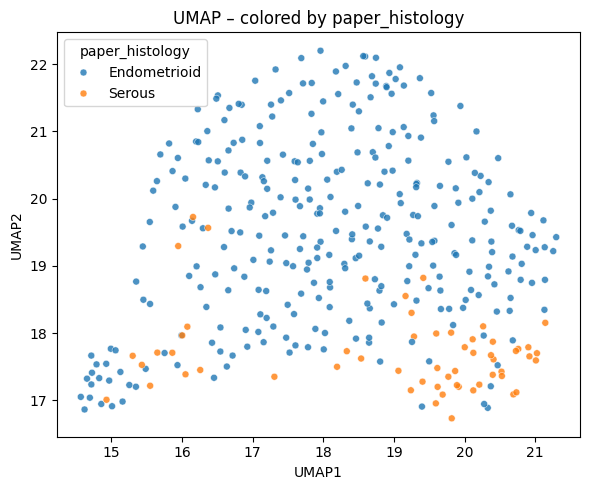

In [3]:
gene_var = X.var(axis=0)
hvg = gene_var.sort_values(ascending=False).head(5000).index
X_hvg = X[hvg]

X_norm = X_hvg


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_norm)

pca_df = pd.DataFrame(
    X_pca,
    index=X_norm.index,
    columns=["PC1", "PC2"]
)

import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.3,
    random_state=42
)

X_umap = reducer.fit_transform(X_norm)

umap_df = pd.DataFrame(
    X_umap,
    index=X_norm.index,
    columns=["UMAP1", "UMAP2"]
)

# ---- CHOISIR LA COLONNE ----
color_col = "paper_histology"

plot_df = umap_df.join(clinical[color_col])

plt.figure(figsize=(6,5))
sns.scatterplot(
    data=plot_df,
    x="UMAP1", y="UMAP2",
    hue=color_col,
    s=25, alpha=0.8
)
plt.title(f"UMAP – colored by {color_col}")
plt.tight_layout()
plt.show()


# 5. Stratégie d’apprentissage supervisé

Le nombre de gènes mesurés étant très supérieur au nombre de patients (p ≫ n), l’apprentissage supervisé direct sur l’ensemble des gènes expose à un risque important d’overfitting.

Pour limiter ce risque, nous utilisons :

-une sélection supervisée de variables basée sur un test ANOVA,

-des métriques adaptées au déséquilibre de classes, telles que le F1-score macro, l’AUC ROC et la balanced accuracy.

Les performances sont évaluées à l’aide d’un split simple (sanity check), puis d’une validation croisée stratifiée.

# 6. Split simple (sanity check)

Un premier split stratifié apprentissage / test est réalisé afin de vérifier le bon fonctionnement des pipelines et d’obtenir une première estimation des performances.

### 6.1 Split train/test stratifié

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### 6.2 ANOVA sur le train (top 500)

La sélection des gènes est effectuée uniquement sur le jeu d’entraînement, en classant les gènes selon la statistique F issue d’un test ANOVA.
Les 500 gènes les plus discriminants sont retenus.Un réseau de neurones multicouche est entraîné sur les gènes sélectionnés.
L’entraînement est régularisé par dropout et early stopping afin de limiter l’overfitting.

In [5]:
k = 500
anova = SelectKBest(score_func=f_classif, k=k)

X_train_sel = anova.fit_transform(X_train, y_train)
X_test_sel  = anova.transform(X_test)

selected_genes = X_train.columns[anova.get_support()]

### 6.3 MLP – résultats

Un réseau de neurones multicouche est entraîné sur les gènes sélectionnés.
L’entraînement est régularisé par dropout et early stopping afin de limiter l’overfitting.

In [6]:
model = Sequential([
    Input(shape=(X_train_sel.shape[1],)),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_sel, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

y_proba_mlp = model.predict(X_test_sel).ravel()
y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)

print("MLP ROC-AUC:", roc_auc_score(y_test, y_proba_mlp))
print(classification_report(y_test, y_pred_mlp))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
MLP ROC-AUC: 0.998533724340176
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        62
           1       1.00      0.91      0.95        11

    accuracy                           0.99        73
   macro avg       0.99      0.95      0.97        73
weighted avg       0.99      0.99      0.99        73



### 6.4 Régression logistique – résultats

Une régression logistique est entraînée sur les mêmes gènes sélectionnés, servant de modèle linéaire de référence.

Les performances sont évaluées sur le jeu de test à l’aide de matrices de confusion et de métriques standard.

In [7]:
logreg = LogisticRegression(
    max_iter=2000,
    solver="liblinear"
)

logreg.fit(X_train_sel, y_train)

y_proba_lr = logreg.predict_proba(X_test_sel)[:, 1]
y_pred_lr = (y_proba_lr >= 0.5).astype(int)

print("LogReg ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print(classification_report(y_test, y_pred_lr))


LogReg ROC-AUC: 0.9956011730205279
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        62
           1       0.69      1.00      0.81        11

    accuracy                           0.93        73
   macro avg       0.84      0.96      0.89        73
weighted avg       0.95      0.93      0.94        73



### 6.5 Figures

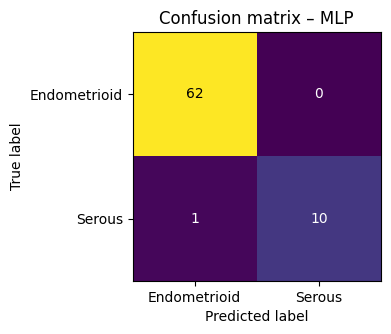

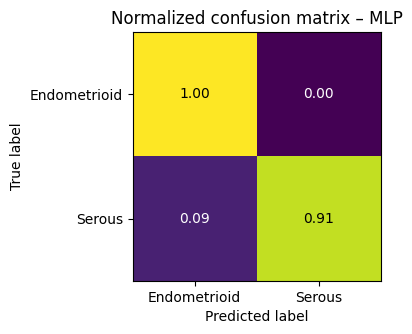

In [8]:
#1 Matrice de confusion MLP
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm_mlp)

ax.set_title("Confusion matrix – MLP")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Endometrioid", "Serous"])
ax.set_yticklabels(["Endometrioid", "Serous"])

# Seuil pour le contraste texte
threshold = cm_mlp.max() / 2

for i in range(2):
    for j in range(2):
        value = int(cm_mlp[i, j])  # entier strict
        color = "black" if cm_mlp[i, j] > threshold else "white"
        ax.text(
            j, i, value,
            ha="center", va="center",
            color=color
        )

plt.tight_layout()
plt.show()

#2 Matrice de confusion MLP normalisée
cm_norm_mlp = confusion_matrix(y_test, y_pred_mlp, normalize="true")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm_norm_mlp)

ax.set_title("Normalized confusion matrix – MLP")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Endometrioid", "Serous"])
ax.set_yticklabels(["Endometrioid", "Serous"])

threshold = cm_norm_mlp.max() / 2

for i in range(2):
    for j in range(2):
        color = "black" if cm_norm_mlp[i, j] > threshold else "white"
        ax.text(j, i, f"{cm_norm_mlp[i, j]:.2f}",
                ha="center", va="center",
                color=color)

plt.tight_layout()
plt.show()

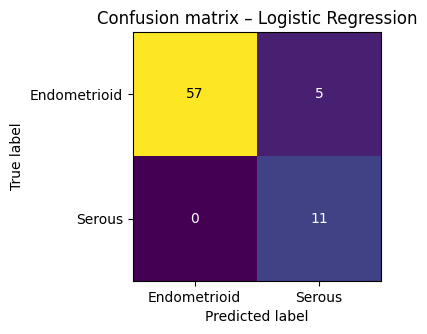

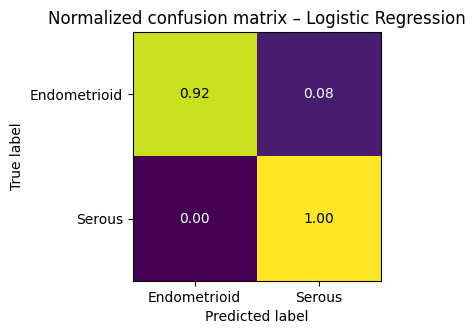

In [9]:
#2 Matrice de confusion logreg 
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm_lr)

ax.set_title("Confusion matrix – Logistic Regression")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Endometrioid", "Serous"])
ax.set_yticklabels(["Endometrioid", "Serous"])

# Seuil pour le contraste texte
threshold = cm_lr.max() / 2

for i in range(2):
    for j in range(2):
        value = int(cm_lr[i, j])  # entier strict
        color = "black" if cm_lr[i, j] > threshold else "white"
        ax.text(
            j, i, value,
            ha="center", va="center",
            color=color
        )

plt.tight_layout()
plt.show()

#2 Matrice de confusion logreg normalisée
cm_norm_lr = confusion_matrix(y_test, y_pred_lr, normalize="true")

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm_norm_lr)

ax.set_title("Normalized confusion matrix – Logistic Regression")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Endometrioid", "Serous"])
ax.set_yticklabels(["Endometrioid", "Serous"])

# seuil = moitié de la valeur max
threshold = cm_norm_lr.max() / 2

for i in range(2):
    for j in range(2):
        color = "black" if cm_norm_lr[i, j] > threshold else "white"
        ax.text(j, i, f"{cm_norm_lr[i, j]:.2f}",
                ha="center", va="center",
                color=color)

plt.tight_layout()
plt.show()



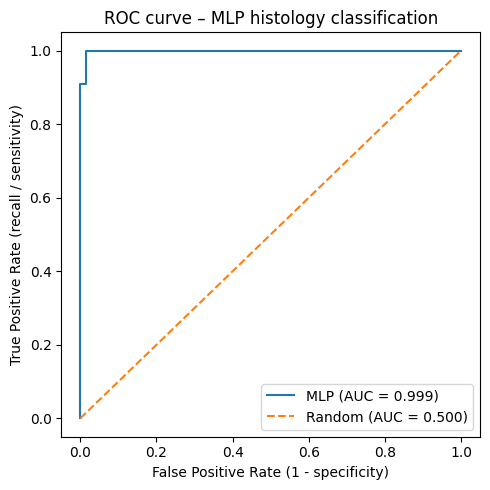

In [10]:
# Calcul ROC MLP seul
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)
auc_mlp = roc_auc_score(y_test, y_proba_mlp)

# Plot
plt.figure(figsize=(5, 5))
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP (AUC = {auc_mlp:.3f})")

# Diagonale hasard
plt.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC = 0.500)")

plt.xlabel("False Positive Rate (1 - specificity)")
plt.ylabel("True Positive Rate (recall / sensitivity)")
plt.title("ROC curve – MLP histology classification")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

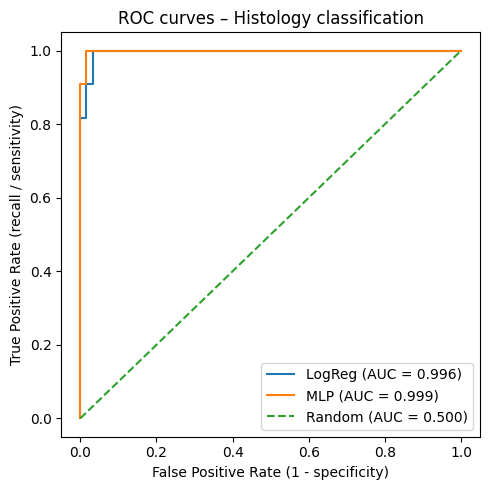

In [11]:
# --- ROC + AUC Logistic Regression ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

# --- ROC + AUC MLP ---
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)
auc_mlp = roc_auc_score(y_test, y_proba_mlp)

# --- Plot ---
plt.figure(figsize=(5, 5))
plt.plot(fpr_lr, tpr_lr, label=f"LogReg (AUC = {auc_lr:.3f})")
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP (AUC = {auc_mlp:.3f})")

# Diagonale "hasard"
plt.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC = 0.500)")

plt.xlabel("False Positive Rate (1 - specificity)")
plt.ylabel("True Positive Rate (recall / sensitivity)")
plt.title("ROC curves – Histology classification")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

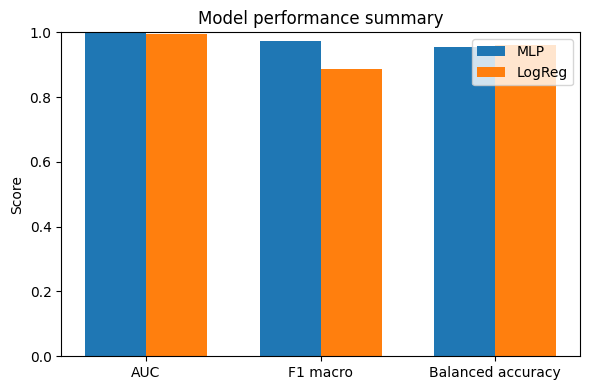

In [12]:
metrics = {
    "AUC": [
        roc_auc_score(y_test, y_proba_mlp),
        roc_auc_score(y_test, y_proba_lr)
    ],
    "F1 macro": [
        f1_score(y_test, y_pred_mlp, average="macro"),
        f1_score(y_test, y_pred_lr, average="macro")
    ],
    "Balanced accuracy": [
        balanced_accuracy_score(y_test, y_pred_mlp),
        balanced_accuracy_score(y_test, y_pred_lr)
    ]
}

models = ["MLP", "LogReg"]

x = np.arange(len(metrics))  # positions des métriques
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))

mlp_values = [metrics[m][0] for m in metrics]
lr_values  = [metrics[m][1] for m in metrics]

ax.bar(x - width/2, mlp_values, width, label="MLP")
ax.bar(x + width/2, lr_values,  width, label="LogReg")

ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Model performance summary")

ax.legend()
plt.tight_layout()
plt.show()

# 7. Validation croisée stratifiée (résultats robustes)

Afin d’obtenir une estimation plus robuste des performances, une validation croisée stratifiée est mise en place. D'abord les mêmes hyperparamètres que ceux définit pour le modèle simple sont utilisés, puis une exploration des hyperparamètres est réalisée, d'abord en modifiant le nombre de couches puis en utilisant la fonction RandomSearch pour identifier une combinaison de parametres meilleures.

### 7.1 Pipeline Cross validation

La sélection de gènes par ANOVA est intégrée directement dans le pipeline de validation croisée, ce qui permet d’éviter toute fuite d’information entre les ensembles d’apprentissage et de test.

In [13]:
# ---------------------------
# 1) Modèle MLP sous forme de fonction
# ---------------------------
def build_mlp_binary(meta,
                     n_hidden1: int = 128,
                     n_hidden2: int = 32,
                     dropout1: float = 0.2,
                     dropout2: float = 0.2,
                     learning_rate: float = 1e-3) -> keras.Model:
    n_features = meta["n_features_in_"] 

    model = keras.Sequential([
        keras.Input(shape=(n_features,)),
        layers.Dense(n_hidden1, activation="relu"),
        layers.Dropout(dropout1),
        layers.Dense(n_hidden2, activation="relu"),
        layers.Dropout(dropout2),
        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")]
    )
    return model

early_stop = EarlyStopping(monitor="loss", patience=10, restore_best_weights=True)

# ---------------------------
# 2) Wrapper SciKeras
# ---------------------------
mlp_clf = KerasClassifier(
    model=build_mlp_binary,
    verbose=0,
    callbacks=[early_stop],
    epochs=200,
    batch_size=32,
)


# ---------------------------
# 3) Pipeline scikit-learn 
# ---------------------------
# Tout ce qui apprend doit être dans la pipeline :
# - StandardScaler : fit sur train_fold uniquement
# - SelectKBest(f_classif) : ANOVA fit sur train_fold uniquement
# - MLP : entraîné sur train_fold uniquement
pipe = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("anova", SelectKBest(score_func=f_classif, k=500)),
    ("mlp", mlp_clf),
])

### 7.2 Performances en CV

In [14]:
# ---------------------------
# 4) Cross-validation
# ---------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def auc_from_proba(estimator, X, y):
    proba = estimator.predict_proba(X)[:, 1]
    return roc_auc_score(y, proba)

def acc_from_proba(estimator, X, y):
    proba = estimator.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return accuracy_score(y, pred)

def balacc_from_proba(estimator, X, y):
    proba = estimator.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return balanced_accuracy_score(y, pred)


scoring = {
    "roc_auc": auc_from_proba,
    "acc": acc_from_proba,
    "bal_acc": balacc_from_proba,
}

cv_results1 = cross_validate(
    estimator=pipe,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score="raise",
)


print("cv_results1")
for k in scoring:
    mean_ = np.mean(cv_results1[f"test_{k}"])
    std_  = np.std(cv_results1[f"test_{k}"])
    print(f"{k}: {mean_:.3f} ± {std_:.3f}")


cv_results1
roc_auc: 0.962 ± 0.039
acc: 0.945 ± 0.020
bal_acc: 0.923 ± 0.033


### 7.3 Exploration des hyperparamètres

#### 7.3.1 Nombre de couches différents

3 hidden layers

In [15]:
def build_mlp_tuning_layers(meta,
                     n_hidden1: int = 128,
                     n_hidden2: int = 64,
                     n_hidden3: int = 32,     
                     dropout1: float = 0.2,
                     dropout2: float = 0.2,
                     dropout3: float = 0.2,
                     learning_rate: float = 1e-3) -> keras.Model:
    n_features = meta["n_features_in_"] 

    model = keras.Sequential([
        keras.Input(shape=(n_features,)),
        layers.Dense(n_hidden1, activation="relu"),
        layers.Dropout(dropout1),
        layers.Dense(n_hidden2, activation="relu"),  
        layers.Dropout(dropout2),
        layers.Dense(n_hidden3, activation="relu"),
        layers.Dropout(dropout3),
        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")]
    )
    return model

early_stop = EarlyStopping(monitor="loss", patience=10, restore_best_weights=True)


mlp_clf = KerasClassifier(
    model=build_mlp_tuning_layers,
    verbose=0,
    callbacks=[early_stop],
    epochs=200,
    batch_size=32,
)

pipe = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("anova", SelectKBest(score_func=f_classif, k=500)),
    ("mlp", mlp_clf),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def auc_from_proba(estimator, X, y):
    proba = estimator.predict_proba(X)[:, 1]
    return roc_auc_score(y, proba)

def acc_from_proba(estimator, X, y):
    proba = estimator.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return accuracy_score(y, pred)

def balacc_from_proba(estimator, X, y):
    proba = estimator.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return balanced_accuracy_score(y, pred)


scoring = {
    "roc_auc": auc_from_proba,
    "acc": acc_from_proba,
    "bal_acc": balacc_from_proba,
}

cv_results2= cross_validate(
    estimator=pipe,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score="raise",
)

print("cv_results2")
for k in scoring:
    mean_ = np.mean(cv_results2[f"test_{k}"])
    std_  = np.std(cv_results2[f"test_{k}"])
    print(f"{k}: {mean_:.3f} ± {std_:.3f}")

cv_results2
roc_auc: 0.962 ± 0.038
acc: 0.952 ± 0.013
bal_acc: 0.953 ± 0.038


1 hidden layer

In [16]:
def build_mlp_tuning_layers(meta,
                     n_hidden1: int = 1024,     
                     dropout1: float = 0.2,
                     learning_rate: float = 1e-3) -> keras.Model:
    n_features = meta["n_features_in_"] 

    model = keras.Sequential([
        keras.Input(shape=(n_features,)),
        layers.Dense(n_hidden1, activation="relu"),
        layers.Dropout(dropout1),
        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")]
    )
    return model

early_stop = EarlyStopping(monitor="loss", patience=10, restore_best_weights=True)


mlp_clf = KerasClassifier(
    model=build_mlp_tuning_layers,
    verbose=0,
    callbacks=[early_stop],
    epochs=200,
    batch_size=32,
)

pipe = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("anova", SelectKBest(score_func=f_classif, k=500)),
    ("mlp", mlp_clf),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def auc_from_proba(estimator, X, y):
    proba = estimator.predict_proba(X)[:, 1]
    return roc_auc_score(y, proba)

def acc_from_proba(estimator, X, y):
    proba = estimator.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return accuracy_score(y, pred)

def balacc_from_proba(estimator, X, y):
    proba = estimator.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return balanced_accuracy_score(y, pred)


scoring = {
    "roc_auc": auc_from_proba,
    "acc": acc_from_proba,
    "bal_acc": balacc_from_proba,
}

cv_results3= cross_validate(
    estimator=pipe,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score="raise",
)

print("cv_results3")
for k in scoring:
    mean_ = np.mean(cv_results3[f"test_{k}"])
    std_  = np.std(cv_results3[f"test_{k}"])
    print(f"{k}: {mean_:.3f} ± {std_:.3f}")

cv_results3
roc_auc: 0.962 ± 0.040
acc: 0.945 ± 0.020
bal_acc: 0.932 ± 0.041


#### 7.3.2 RandomSearch

In [17]:
def build_mlp_binary(meta,
                     n_hidden1=128,
                     n_hidden2=32,
                     dropout1=0.2,
                     dropout2=0.2,
                     learning_rate=1e-3):

    n_features = meta["n_features_in_"]

    model = keras.Sequential([
        keras.Input(shape=(n_features,)),
        layers.Dense(n_hidden1, activation="relu"),
        layers.Dropout(dropout1),
        layers.Dense(n_hidden2, activation="relu"),
        layers.Dropout(dropout2),
        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")]
    )
    return model

early_stop = EarlyStopping(
    monitor="loss",
    patience=10,
    restore_best_weights=True
)

mlp_clf = KerasClassifier(
    model=build_mlp_binary,
    verbose=0,
    callbacks=[early_stop],
    epochs=200,
    batch_size=32,

    # paramètres du build_fn
    model__n_hidden1=128,
    model__n_hidden2=32,
    model__dropout1=0.2,
    model__dropout2=0.2,
    model__learning_rate=1e-3,
)

pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("anova", SelectKBest(score_func=f_classif, k=500)),
    ("mlp", mlp_clf),
])

param_distributions = {

    # Architecture
    "mlp__model__n_hidden1": randint(64, 193),
    "mlp__model__n_hidden2": randint(16, 65),

    # Régularisation
    "mlp__model__dropout1": uniform(0.2, 0.4),
    "mlp__model__dropout2": uniform(0.1, 0.3),

    # Optimisation
    "mlp__model__learning_rate": uniform(3e-4, 1e-3),

    # Entraînement
    "mlp__batch_size": [16, 32],
    "mlp__epochs": [80, 120, 150],
}

def auc_from_proba(estimator, X, y):
    proba = estimator.predict_proba(X)[:, 1]
    return roc_auc_score(y, proba)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=12,
    scoring=auc_from_proba,
    cv=cv,
    random_state=42,
    n_jobs=1,        # IMPORTANT avec Keras
    refit=True,
    verbose=1,
)

random_search.fit(X_train, y_train)

print("Best CV AUC:", random_search.best_score_)
print("Best params:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

best_pipe = random_search.best_estimator_


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best CV AUC: 0.9736961451247165
Best params:
  mlp__batch_size: 16
  mlp__epochs: 80
  mlp__model__dropout1: 0.5208787923016158
  mlp__model__dropout2: 0.12236519310393125
  mlp__model__learning_rate: 0.0012868869366005173
  mlp__model__n_hidden1: 151
  mlp__model__n_hidden2: 16


In [18]:
mlp_clf.get_params().keys()
pipe.named_steps

{'scaler': StandardScaler(),
 'anova': SelectKBest(k=500),
 'mlp': KerasClassifier(
 	model=<function build_mlp_binary at 0x2db734790>
 	build_fn=None
 	warm_start=False
 	random_state=None
 	optimizer=rmsprop
 	loss=None
 	metrics=None
 	batch_size=32
 	validation_batch_size=None
 	verbose=0
 	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x29548cd00>]
 	validation_split=0.0
 	shuffle=True
 	run_eagerly=False
 	epochs=200
 	model__n_hidden1=128
 	model__n_hidden2=32
 	model__dropout1=0.2
 	model__dropout2=0.2
 	model__learning_rate=0.001
 	class_weight=None
 )}

### 7.4 Choix du modèle final + Figures

Les résultats peuvent varier en fonction de l'initialisation des poids aléatoires, de l'ordre des batch, de l'optimiseur Adam qui est stochastique et enfin des 5 folds qui amplifient ces différences.

/var/folders/b2/c5phybp105120c0c2t6xw7w40000gn/T/ipykernel_70107/3309049634.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr = y_train[tr_idx]
/var/folders/b2/c5phybp105120c0c2t6xw7w40000gn/T/ipykernel_70107/3309049634.py:48: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_va = y_train[va_idx]
/var/folders/b2/c5phybp105120c0c2t6xw7w40000gn/T/ipykernel_70107/3309049634.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_t

CV ROC AUC: 0.975 ± 0.019


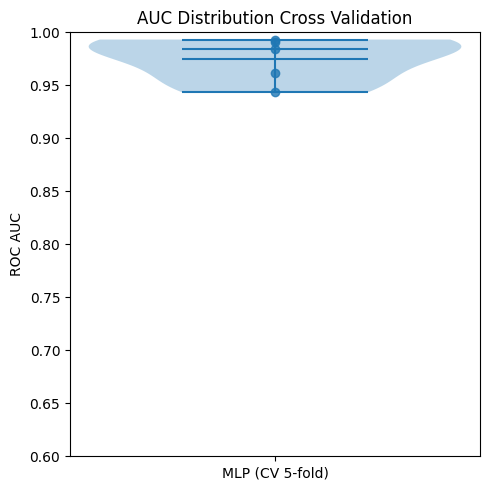

In [19]:
def build_mlp_binary(meta,
                     n_hidden1: int = 128,
                     n_hidden2: int = 32,
                     dropout1: float = 0.2,
                     dropout2: float = 0.2,
                     learning_rate: float = 1e-3) -> keras.Model:
    n_features = meta["n_features_in_"] 

    model = keras.Sequential([
        keras.Input(shape=(n_features,)),
        layers.Dense(n_hidden1, activation="relu"),
        layers.Dropout(dropout1),
        layers.Dense(n_hidden2, activation="relu"),
        layers.Dropout(dropout2),
        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")]
    )
    return model

early_stop = EarlyStopping(monitor="loss", patience=10, restore_best_weights=True)

mlp_clf = KerasClassifier(
    model=build_mlp_binary,
    verbose=0,
    callbacks=[early_stop],
    epochs=200,
    batch_size=32,
)


pipe = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("anova", SelectKBest(score_func=f_classif, k=500)),
    ("mlp", mlp_clf),
])

auc_folds = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), start=1):
    X_tr = X_train.iloc[tr_idx]
    X_va = X_train.iloc[va_idx]
    y_tr = y_train[tr_idx]
    y_va = y_train[va_idx]

    pipe.fit(X_tr, y_tr)
    y_proba = pipe.predict_proba(X_va)[:, 1]
    auc = roc_auc_score(y_va, y_proba)

    auc_folds.append(auc)

auc_folds = np.array(auc_folds)
mean_auc = auc_folds.mean()
std_auc  = auc_folds.std()
print(f"CV ROC AUC: {mean_auc:.3f} ± {std_auc:.3f}")


plt.figure(figsize=(5, 5))
plt.violinplot(auc_folds, showmeans=True, showmedians=True)
plt.xticks([1], ["MLP (CV 5-fold)"])
plt.ylabel("ROC AUC")
plt.title("AUC Distribution Cross Validation")


plt.scatter(np.ones_like(auc_folds), auc_folds, alpha=0.8)

plt.ylim(0.6, 1.0)  
plt.tight_layout()
plt.show()

Une exploration limitée de certains hyperparamètres du MLP est réalisée (taille des couches, taux de dropout, learning rate, nombre de gènes sélectionnés), afin d’évaluer la sensibilité des performances sans chercher une optimisation exhaustive. L'outil GridSearch a d'abord été ut




D'autres hyperparamètres ont été testé à la main, telles que le nombre de couches de neurones et les fonctions d'activation (tanh, sigmoid, gelu).

# 8. Entraînement du modèle final

Une fois la stratégie validée par la validation croisée, des modèles finaux sont entraînés à partir de zéro sur l’ensemble du jeu de données, en utilisant les hyperparamètres retenus.

Cette étape n’a pas pour objectif d’évaluer les performances, mais de permettre une interprétation plus stable du signal biologique appris par les modèles.

In [20]:
# 1) Sélection ANOVA sur tout le dataset (pour interprétation)
k = 500
anova = SelectKBest(score_func=f_classif, k=k)
anova.fit(X, y)
selected_genes = X.columns[anova.get_support()]
X_500 = X[selected_genes]

# 2) Fit MLP (une seule fois) sur X_500
pipe_500 = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("mlp", mlp_clf),
])
pipe_500.fit(X_500, y)

# 3) Scorer AUC compatible SciKeras
def scikeras_auc_scorer(estimator, X, y):
    """
    Custom ROC-AUC scorer compatible with SciKeras.
    """
    proba = estimator.predict_proba(X)

    # Cas binaire SciKeras
    if proba.ndim == 2 and proba.shape[1] == 2:
        proba = proba[:, 1]
    else:
        proba = proba.ravel()

    return roc_auc_score(y, proba)


# 9. Interprétation des modèles

### 9.1 Importance par permutation - MLP

L’interprétation du MLP est réalisée à l’aide d’une approche par importance des variables par permutation.
Cette méthode consiste à mesurer la baisse de performance induite par la permutation d’un gène, afin d’estimer son influence sur les prédictions du réseau.

In [21]:
perm = permutation_importance(
    estimator=pipe_500,
    X=X_500,
    y=y,
    scoring=scikeras_auc_scorer,
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

imp_df = pd.DataFrame({
    "gene": selected_genes,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("Top 20 genes by permutation importance:")
print(imp_df.head(20))

Top 20 genes by permutation importance:
         gene  importance_mean  importance_std
188      RHOF         0.001474        0.000269
398  POT1-AS1         0.000789        0.000127
341     CLDN6         0.000720        0.000058
20     ATP2C2         0.000663        0.000093
168     MRAP2         0.000617        0.000159
292    ADRA1B         0.000606        0.000106
337     KCNQ3         0.000594        0.000156
70      INTS9         0.000594        0.000203
378    GPRIN2         0.000583        0.000221
113    PIK3R3         0.000549        0.000058
130    CDKN1A         0.000514        0.000102
262     NUDT2         0.000514        0.000153
3       SCN4A         0.000503        0.000246
284     THBS3         0.000491        0.000545
173    WNT10A         0.000469        0.000209
44      DOCK3         0.000469        0.000215
112     ACTL8         0.000457        0.000036
349    RGS9BP         0.000446        0.000193
437  TMEM150C         0.000446        0.000105
191      GRB7       

### 9.2 Lecture de coefficients - Régression logistique

Les coefficients de la régression logistique sont analysés afin d’identifier les gènes contribuant le plus à la discrimination entre les types histologiques.
Le signe et l’amplitude des coefficients permettent une interprétation directe du sens de l’association.

In [22]:
pipe_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(solver="liblinear", max_iter=2000))
])
pipe_logreg.fit(X_500, y)

coef = pipe_logreg.named_steps["logreg"].coef_.ravel()
logreg_coef_df = pd.DataFrame({
    "gene": X_500.columns,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

logreg_top20 = list(logreg_coef_df["gene"].head(20))
print("LogReg top20 by |coef|:", logreg_top20[:10], "...")


LogReg top20 by |coef|: ['SGCG', 'MIR34AHG', 'AC067930.9', 'JPH3', 'POT1-AS1', 'UGT3A1', 'RGS9BP', 'POP4', 'MACROD2', 'LINC01257'] ...


### 9.2 Importance par permutation - Régression logistique

In [23]:
perm_lr = permutation_importance(
    pipe_logreg,
    X_500,
    y,
    scoring="roc_auc",   
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

logreg_perm_df = pd.DataFrame({
    "gene": X_500.columns,
    "importance_mean": perm_lr.importances_mean,
    "importance_std": perm_lr.importances_std
}).sort_values("importance_mean", ascending=False)

print(logreg_perm_df.head(20))


/opt/anaconda3/envs/jup_dl_tcga/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


         gene  importance_mean  importance_std
0       MEOX1              0.0             0.0
329     GPR19              0.0             0.0
342    CLCNKB              0.0             0.0
341     CLDN6              0.0             0.0
340    GPR173              0.0             0.0
339    CRELD2              0.0             0.0
338  C1QTNF12              0.0             0.0
337     KCNQ3              0.0             0.0
336   KIRREL1              0.0             0.0
335     PNMA3              0.0             0.0
334    MRPL54              0.0             0.0
333    TENT5C              0.0             0.0
332       MX2              0.0             0.0
331   CCDC125              0.0             0.0
330     SMDT1              0.0             0.0
328    SLC8A1              0.0             0.0
313   DSCAML1              0.0             0.0
327      MAFA              0.0             0.0
326      EXT1              0.0             0.0
325     PLAG1              0.0             0.0


### 9.3 Comparaison des signaux appris

Les gènes importants identifiés par les deux modèles sont comparés afin d’évaluer :

-les signaux communs,

-les contributions spécifiques capturées par le modèle non linéaire.
Les résultats peuvent varier car les modèles ne sont pas totalement déterministes.

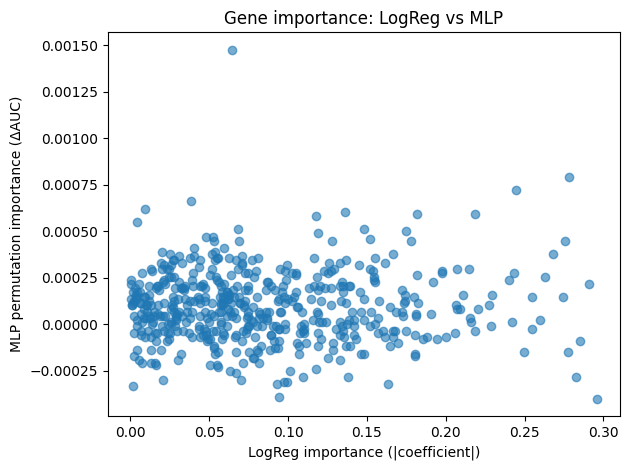

In [24]:
merged = pd.merge(
    logreg_coef_df[["gene", "abs_coef"]],
    imp_df[["gene", "importance_mean"]],
    on="gene"
)

plt.figure()
plt.scatter(
    merged["abs_coef"],
    merged["importance_mean"],
    alpha=0.6
)
plt.xlabel("LogReg importance (|coefficient|)")
plt.ylabel("MLP permutation importance (ΔAUC)")
plt.title("Gene importance: LogReg vs MLP")
plt.tight_layout()
plt.show()


In [25]:
mlp_top20 = set(imp_df.head(20)["gene"])
logreg_top20 = set(logreg_coef_df.head(20)["gene"])

common = mlp_top20.intersection(logreg_top20)

print(f"Genes communs dans le top20 : {len(common)}")
print(common)

Genes communs dans le top20 : 3
{'RGS9BP', 'CLDN6', 'POT1-AS1'}


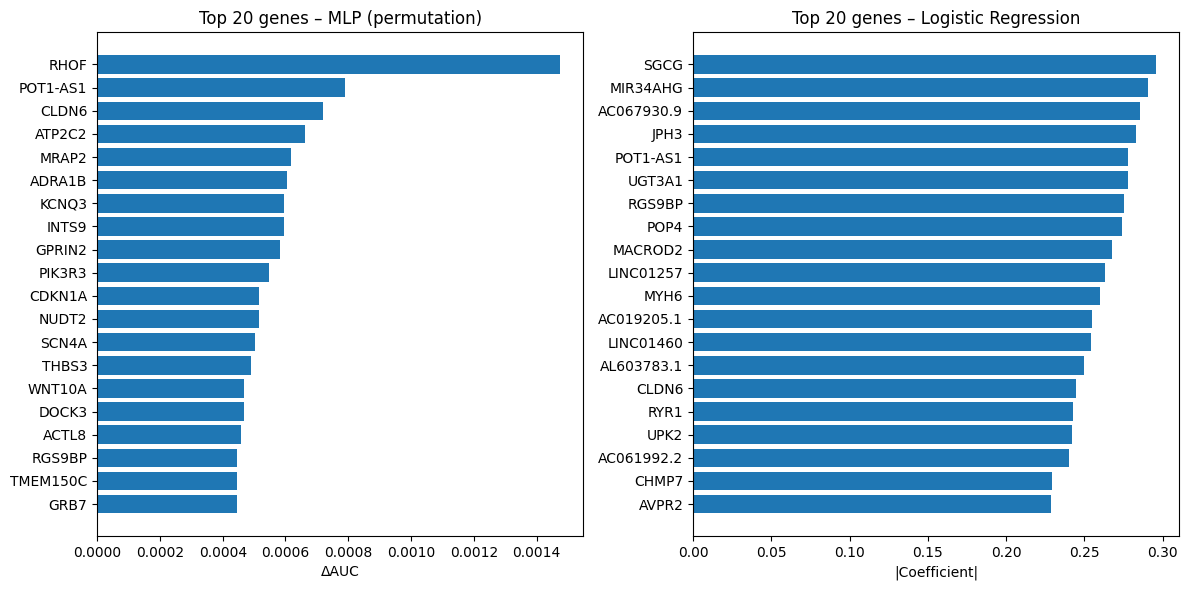

In [26]:
top_k =20

# Top MLP
mlp_genes = imp_df.head(top_k)["gene"].values
mlp_vals = imp_df.head(top_k)["importance_mean"].values

# Top LogReg
lr_genes = logreg_coef_df.head(top_k)["gene"].values
lr_vals = logreg_coef_df.head(top_k)["abs_coef"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

# --- MLP ---
axes[0].barh(mlp_genes[::-1], mlp_vals[::-1])
axes[0].set_title("Top 20 genes – MLP (permutation)")
axes[0].set_xlabel("ΔAUC")

# --- LogReg ---
axes[1].barh(lr_genes[::-1], lr_vals[::-1])
axes[1].set_title("Top 20 genes – Logistic Regression")
axes[1].set_xlabel("|Coefficient|")

plt.tight_layout()
plt.show()